# Native format parity

XDMF2 references and Netgen periodic/name tables now work in the native readers. PCD LZF and parameterized glTF export are also available in the flat bindings. This synthetic example needs no downloaded fixture; a coloured triangle and its periodic node pair make the metadata visible.

In [1]:
import os
import tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import meshioplusplus as mp
from meshioplusplus import _core as native_core

os.environ['PYVISTA_OFF_SCREEN'] = 'true'
workspace = tempfile.TemporaryDirectory()
root = Path(workspace.name)
points = np.array([[0., 0., 0.], [1., 0., 0.], [0., 1., 0.]])
mesh = mp.Mesh(points, [('triangle', np.array([[0, 1, 2]]))],
    point_data={'temperature': np.array([0., 1., 2.])},
    cell_data={'netgen:index': [np.array([2])]}, field_data={'wall': [2, 2]},
    info={'netgen:identifications': np.array([[1, 2, 1]]),
          'netgen:identificationtypes': np.array([[2]])})


## XDMF2 reference resolution
Geometry references an attribute's DataItem. The strict-core environment makes accidental Python fallback an error.

In [2]:
xdmf = root / 'reference.xdmf'
xdmf.write_text('''<Xdmf Version="2.0"><Domain><Grid>
<Topology TopologyType="Triangle"><DataItem NumberType="Int" Dimensions="1 3" Format="XML">0 1 2</DataItem></Topology>
<Geometry GeometryType="XYZ"><DataItem Reference="XML">/Xdmf/Domain/Grid/Attribute/DataItem</DataItem></Geometry>
<Attribute Name="coordinates" Center="Node"><DataItem NumberType="Float" Precision="8" Dimensions="3 3" Format="XML">0 0 0 1 0 0 0 1 0</DataItem></Attribute>
</Grid></Domain></Xdmf>''')
previous = os.environ.get('MESHIOPLUSPLUS_STRICT_CORE')
os.environ['MESHIOPLUSPLUS_STRICT_CORE'] = '1'
try:
    referenced = mp.read(xdmf)
    np.testing.assert_array_equal(referenced.points, points)
    vol = root / 'periodic.vol'
    mp.write(vol, mesh)
    periodic = mp.read(vol)
finally:
    if previous is None:
        os.environ.pop('MESHIOPLUSPLUS_STRICT_CORE', None)
    else:
        os.environ['MESHIOPLUSPLUS_STRICT_CORE'] = previous
np.testing.assert_array_equal(periodic.info['netgen:identifications'], [[1, 2, 1]])
print('Native XDMF2 geometry:', referenced.points.shape)
print('Netgen names:', periodic.field_data)
print('Periodic file node ids (1-based):', periodic.info['netgen:identifications'])


Native XDMF2 geometry: (3, 3)
Netgen names: {'wall': array([2, 2])}
Periodic file node ids (1-based): [[1 2 1]]


## Portable compressed and coloured exports
Pipeline `Output.Codec='lzf'` selects PCD binary_compressed. The same native options are exposed as `MIO_CODEC_LZF` in C and `codec='lzf'` in the other flat bindings. glTF's field colour, range, axis and scale are now reachable from each language too.

PCD and coloured GLB written: 453 1864 bytes


meshio warning [pcd.cpp:788] PCD holds points only. Skipping triangle cells.


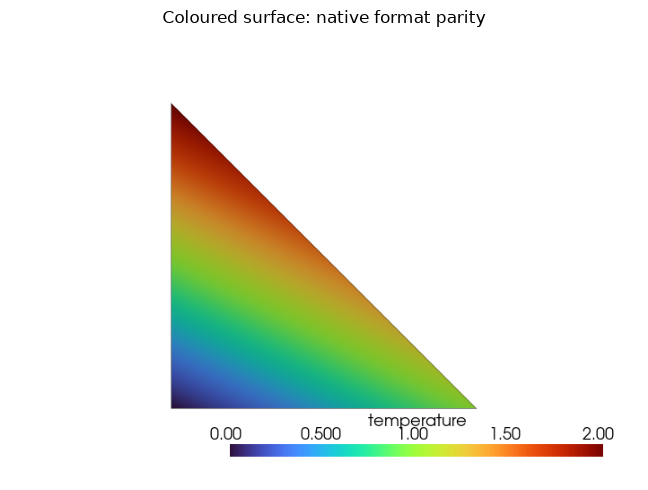

In [3]:
source = root / 'source.vtu'
mp.write(source, mesh)
pcd = root / 'cloud.pcd'
mp.run_pipeline({'Input': {'Path': str(source)}, 'Operations': [],
                 'Output': {'Path': str(pcd), 'Codec': 'lzf'}})
assert b'DATA binary_compressed\n' in pcd.read_bytes()
mp.gltf.write(root / 'colored.glb', mesh, color_by='temperature', cmap='turbo',
              vmin=0, vmax=2, up_axis='z', scale=0.001)
print('PCD and coloured GLB written:', pcd.stat().st_size, (root / 'colored.glb').stat().st_size, 'bytes')

# Embed an off-screen PyVista image, with a matplotlib-only fallback.
try:
    import pyvista as pv
    pv.OFF_SCREEN = True
    grid = pv.PolyData(points, np.array([3, 0, 1, 2]))
    grid['temperature'] = mesh.point_data['temperature']
    plotter = pv.Plotter(off_screen=True, window_size=(700, 500))
    plotter.add_mesh(grid, scalars='temperature', cmap='turbo', clim=[0, 2], show_edges=True)
    plotter.view_xy()
    image = plotter.screenshot(return_img=True)
    plotter.close()
    plt.figure(figsize=(7, 5))
    plt.imshow(image)
    plt.axis('off')
except Exception as exc:
    print('Using matplotlib fallback:', exc)
    plt.figure(figsize=(7, 5))
    plt.tripcolor(points[:, 0], points[:, 1], [[0, 1, 2]], mesh.point_data['temperature'],
                  shading='gouraud', cmap='turbo', vmin=0, vmax=2)
    plt.colorbar(label='temperature')
    plt.axis('equal')
plt.title('Coloured surface: native format parity')
plt.tight_layout()
plt.show()
# Keep the workspace alive for the following sets/data and MED examples.


## Region-backed sets and scalar integer labels
Point/cell sets now have native conversion kernels and flat-binding entry points. Python keeps its mutating Mesh methods and insertion-order labels; the later set wins at overlaps and uncovered entities use -1. Empty sets cannot be reconstructed from labels. Pipelines spell these operations SetsToData and DataToSets; MCP exposes sets_data.

Scalar labels: [0 1 1]
Reconstructed memberships: {'left': array([0]), 'right': array([1, 2])}
Native sets/data dispatch available: True


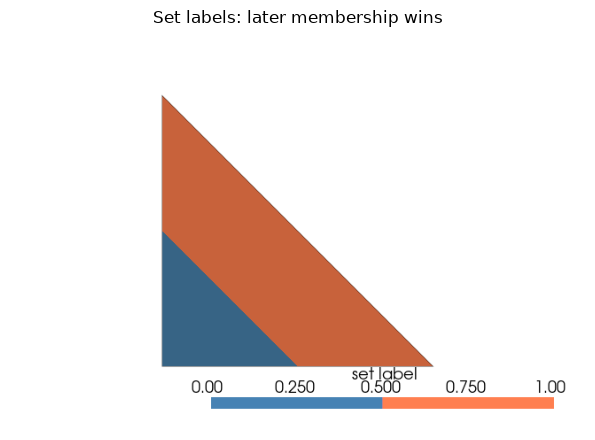

In [4]:
label_mesh = mesh.copy()
label_mesh.point_sets['left'] = [0, 2]
label_mesh.point_sets['right'] = [1, 2]  # right wins at point 2
label_mesh.point_sets_to_data()
labels = label_mesh.point_data['left-right']
np.testing.assert_array_equal(labels, [0, 1, 1])
restored = label_mesh.copy()
restored.point_data_to_sets('left-right')
print('Scalar labels:', labels)
print('Reconstructed memberships:', dict(restored.point_sets))
print('Native sets/data dispatch available:', hasattr(native_core, 'sets_to_data'))
try:
    import pyvista as pv
    pv.OFF_SCREEN = True
    labelled = pv.PolyData(points, np.array([3, 0, 1, 2]))
    labelled['set label'] = labels
    plotter = pv.Plotter(off_screen=True, window_size=(650, 450))
    plotter.add_mesh(labelled, scalars='set label', cmap=['steelblue', 'coral'],
                     categories=True, show_edges=True)
    plotter.view_xy()
    image = plotter.screenshot(return_img=True)
    plotter.close()
    plt.figure(figsize=(6.5, 4.5))
    plt.imshow(image)
    plt.axis('off')
except Exception as exc:
    print('Using matplotlib fallback:', exc)
    plt.figure(figsize=(6.5, 4.5))
    plt.triplot(points[:, 0], points[:, 1], [[0, 1, 2]], color='gray')
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='coolwarm', s=180)
    for i, label in enumerate(labels):
        plt.annotate(str(label), points[i, :2], xytext=(8, 8), textcoords='offset points')
    plt.axis('equal')
plt.title('Set labels: later membership wins')
plt.tight_layout()
plt.show()


## Native MED named meshes and profile expansion
One MED file can contain several independently named meshes. Selecting a named nodal profile expands its one-based indices into full arrays, leaving NaN on uncovered points. The same native APIs are available from the flat language bindings.

Named meshes: ['fluid', 'solid']
Expanded profile: [nan 20. 30.]
Native MED named dispatch available: True


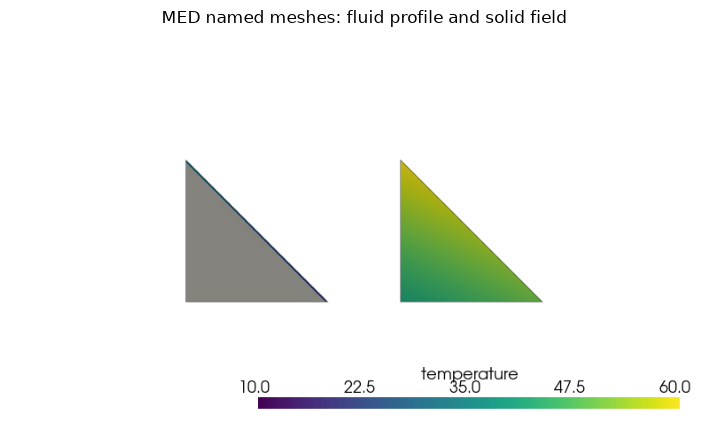

In [5]:
import h5py
med_path = root / 'named.med'
fluid = mp.Mesh(points.copy(), [('triangle', [[0, 1, 2]])],
                point_data={'temperature': np.array([10., 20., 30.])})
solid = mp.Mesh(points.copy() + [1.5, 0., 0.], [('triangle', [[0, 1, 2]])],
                point_data={'temperature': np.array([40., 50., 60.])})
mp.med.write_med_multi(med_path, [fluid, solid], ['fluid', 'solid'])
with h5py.File(med_path, 'r+') as file:
    field = file['CHA/temperature@fluid']
    support = field[next(iter(field))]['NOE']
    support.move('MED_NO_PROFILE_INTERNAL', 'hot_points')
    support.attrs.modify('PFL', np.bytes_('hot_points'))
    profile = support['hot_points']
    del profile['CO']
    profile.create_dataset('CO', data=[20., 30.])
    definition = file.require_group('PROFILS').create_group('hot_points')
    definition.attrs['NBR'] = 2
    definition.create_dataset('PFL', data=np.array([2, 3], dtype=np.int64))
named_meshes, names = mp.med.read_med_multi(med_path)
print('Named meshes:', names)
selected = mp.med.read(med_path, mesh_name='fluid')
np.testing.assert_allclose(selected.point_data['temperature'].reshape(-1), [np.nan, 20., 30.], equal_nan=True)
print('Expanded profile:', selected.point_data['temperature'])
print('Native MED named dispatch available:', hasattr(native_core, 'med_read_named'))
try:
    import pyvista as pv
    plotter = pv.Plotter(off_screen=True, window_size=(800, 450))
    for item in named_meshes:
        surface = pv.PolyData(item.points, np.array([3, 0, 1, 2]))
        surface['temperature'] = item.point_data['temperature'].reshape(-1)
        plotter.add_mesh(surface, scalars='temperature', clim=[10., 60.], show_edges=True)
    plotter.view_xy()
    image = plotter.screenshot(return_img=True)
    plotter.close()
    plt.figure(figsize=(8, 4.5))
    plt.imshow(image)
    plt.axis('off')
except Exception as exc:
    print('Using matplotlib fallback:', exc)
    plt.figure(figsize=(8, 4.5))
    for item in named_meshes:
        plt.triplot(item.points[:, 0], item.points[:, 1], [[0, 1, 2]], color='gray')
        values = item.point_data['temperature'].reshape(-1)
        plt.scatter(item.points[:, 0], item.points[:, 1], c=np.ma.masked_invalid(values),
                    cmap='viridis', vmin=10., vmax=60., s=150, plotnonfinite=True)
    plt.axis('equal')
plt.title('MED named meshes: fluid profile and solid field')
plt.tight_layout()
plt.show()


## Structured pipeline reports
Python and WASM return report objects directly. The additive C report handle runs a pipeline once, then exposes the same steps/warnings as caller-buffer JSON; Fortran, Julia and R copy it into an owned string without rerunning the pipeline.

Python pipeline report: {'steps': [{'op': 'Transform'}], 'warnings': []}
Native caller-buffer report: {'steps': [{'op': 'Transform'}], 'warnings': []}


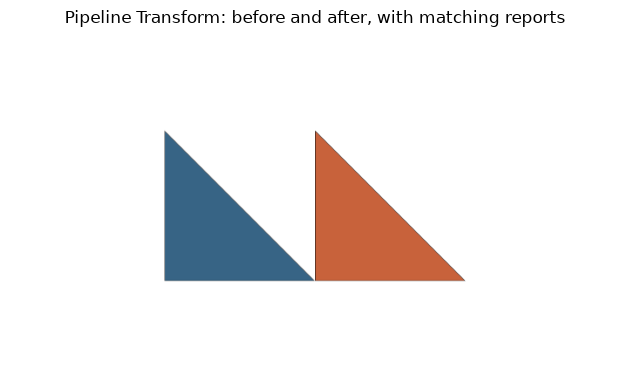

In [6]:
import ctypes, json
pipeline_source, pipeline_target = root / 'source.vtu', root / 'translated.vtu'
mp.write(pipeline_source, fluid, compression=None)
settings = {'Input': {'Path': str(pipeline_source)},
            'Operations': [{'Op': 'Transform', 'Translate': [1., 0., 0.]}],
            'Output': {'Path': str(pipeline_target), 'Codec': 'none'}}
report = mp.run_pipeline(settings)
print('Python pipeline report:', report)
library_path = os.environ.get('MESHIOPLUSPLUS_LIB')
if library_path:
    library = ctypes.CDLL(library_path)
    library.mio_pipeline_run_json_report.argtypes = [ctypes.c_char_p]
    library.mio_pipeline_run_json_report.restype = ctypes.c_void_p
    library.mio_pipeline_report_json.argtypes = [ctypes.c_void_p, ctypes.c_void_p, ctypes.c_int64]
    library.mio_pipeline_report_json.restype = ctypes.c_int64
    library.mio_pipeline_report_free.argtypes = [ctypes.c_void_p]
    owner = library.mio_pipeline_run_json_report(json.dumps(settings).encode())
    assert owner, 'Native report run failed'
    try:
        length = library.mio_pipeline_report_json(owner, None, 0)
        buffer = ctypes.create_string_buffer(length + 1)
        library.mio_pipeline_report_json(owner, buffer, length + 1)
        native_report = json.loads(buffer.value)
        assert native_report == report
        print('Native caller-buffer report:', native_report)
    finally:
        library.mio_pipeline_report_free(owner)
else:
    print('Set MESHIOPLUSPLUS_LIB to exercise the C report handle too.')
translated = mp.read(pipeline_target)
np.testing.assert_allclose(translated.points, fluid.points + [1., 0., 0.])
try:
    import pyvista as pv
    plotter = pv.Plotter(off_screen=True, window_size=(700, 400))
    for item, color in [(fluid, 'steelblue'), (translated, 'coral')]:
        plotter.add_mesh(pv.PolyData(item.points, np.array([3, 0, 1, 2])), color=color, show_edges=True)
    plotter.view_xy()
    image = plotter.screenshot(return_img=True)
    plotter.close()
    plt.figure(figsize=(7, 4))
    plt.imshow(image)
    plt.axis('off')
except Exception as exc:
    print('Using matplotlib fallback:', exc)
    plt.figure(figsize=(7, 4))
    for item, color in [(fluid, 'steelblue'), (translated, 'coral')]:
        plt.triplot(item.points[:, 0], item.points[:, 1], [[0, 1, 2]], color=color)
    plt.axis('equal')
plt.title('Pipeline Transform: before and after, with matching reports')
plt.tight_layout()
plt.show()
workspace.cleanup()
